# Müşteri Kaybı Analizi (Churn Prediction) (Pazarlama Odaklı Sınıflandırma)

Amaç:
- Bu projenin amacı, pazarlama tarafında kritik bir öneme sahip olan "müşteri kaybı (churn)" problemini makine öğrenmesi ile modellemektir.
- Amacımız, bir müşterinin hizmeti bırakıp bırakmayacağını (churn = 1 / 0) geçmiş davranış ve profil bilgilerine bakarak tahmin etmektir.
- Bu örnek hem makine öğrenmesi sınıflandırma adımlarını hem de pazarlama analtiğinin mantığını birlikte öğrenmeyi hedeflemektedir.

Veri seti tanımlama:
- Veri setimiz sentetik olacak
- Toplam örnek sayısı: 1000
  - 500 adet churn = 0 (hizmeti kullanmaya devam eden müşterilelr)
  - 500 adet churn = 1 (hizmeti bırakan müşteriler)
- Dengeli bir veriseti oluştur, herhangi bir sınıf dengesizliği olmasın.
- Features
  1. tenure_months:
    - müşterinin şirkette kaç ay bulunduğunu gösterir.
    - churn = 1 olanlar genelde kısa süre dursun (1 - 20 ay)
    - churn = 0 olanlar daha uzun süre dursun (18 - 60)
  2. monthly_charges:
    - müşterinin aylık fatura tutarı
    - churn 1 olanlar genelde yüksek, churn 0 olanlar ise genelde düşük olacak
  3. contract_type:
    - yıllık ya da aylık sözleşme
    - aylık sözleşmede churn riski yüksek
    - yıllık daha az
  4. has_tech_support
    - yes / no şeklinde olsun
    - teknik destek alma ile ilgili
  5. churn
    - 0 = müşteri kalıyor
    - 1 = müşteri hizmeti bırakıyor

Akış şeması:
1. Gerekli kütüphanelerin içeriye aktarılması
2. Sentetik veri setinin üretilmesi
3. keşifsel veri analizi
  - ilk veri setinin incelenmesi
  - sınıf dağılımlarının öncelenmesi
  - korelasyon matrisinin çizimi
4. Eğitim/test ayrımı ve ön işleme
  - sayısal değişkenler için standard scaler ile normalizasyon
  - kategorik değişkenler için encode etme
5. Karar ağacı algoritmasının eğitilmesi (training)
6. Sonuçların değerlendirilmesi
  - classification report
  - accuracy
  - confusion matrix
  - karar ağaçlarında görselleştirme

In [11]:
#kütüphanelerin içeriye aktarılması
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer  #farklı sütünlara farklı preprocessing adımları uygulamak için
from sklearn.pipeline import Pipeline #preprocessing ile model adımlarını tek bir pipeline da birleştirmek için
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [12]:
# sentetik veri setinin üretimi
def generate_churn_data(n_per_class: int = 500, random_state: int = 0) -> pd.DataFrame:
  """
  Churn veri seti üretme
  Parametreler:
    n_per_class(int):
      - her bir sınıfın üretilecek örnek sayısıdır.
    random_state (int):
      - rastgelelik için kullanılan seed değeri
  Çıktı:
    df (pd.DataFrame): Aşağıdaki sütunlardan oluşan dengeli bir churn verisi döner.
      - tenure_months
      - monthly_charges
      - contract_type
      - has_tech_support
      - churn
  """

  rng = np.random.default_rng(random_state) # rastgele sayı üretmek için generator nesnesi oluşturuyoruz.

  # churn = 0 (stay)
  stay_tenure = rng.integers(18, 60, size = n_per_class) # kalıcı müşteriler için tenure değeri 18-60 ay aralığında olsun
  stay_monthly = rng.uniform(20,80, size = n_per_class) # aylık faturası görece daha düşük olanlar

  stay_contract = rng.choice( # sözleşme tipi
      ["One year", "Month-to-month"], # İki olası değer yıllık veya aylık kontrat
      size = n_per_class,
      p = [0.75, 0.25] # yıllık kontratın olasılığını daha yüksek yapalım
  )
  stay_tech = rng.choice(["Yes","No"], size = n_per_class, p = [0.7,0.3]) # teknik destek durumu

  # churn = 1 (leave)

  churn_tenure = rng.integers(1,20, size = n_per_class) # ayrılan müşteriler için tenure kısa tuttuk
  churn_monthly = rng.uniform(60,120, size = n_per_class) # aylık fature görece yüksek

  churn_contract = rng.choice(["One year", "Month-to-month"], size = n_per_class, p = [0.15,0.85]) # sözleşme tipi
  churn_tech = rng.choice(["Yes","No"], size = n_per_class, p = [0.2,0.8])

  # şimdi dataframeleri oluşturuyoruz
  df_stay = pd.DataFrame({
      "tenure_months": stay_tenure,
      "monthly_charges": stay_monthly,
      "contract_type": stay_contract,
      "has_tech_support": stay_tech,
      "churn": 0
  })

  df_churn = pd.DataFrame({
      "tenure_months": churn_tenure,
      "monthly_charges": churn_monthly,
      "contract_type": churn_contract,
      "has_tech_support": churn_tech,
      "churn": 1
  })

  # iki sınıfı tek bir df de birleştirelim
  df = pd.concat([df_stay, df_churn], ignore_index = True) # iki df alt alta birleştiriyoruz
  df = df.sample (frac = 1, random_state = random_state).reset_index(drop = True) # rastgele karıştırıyoruz

  return df

In [13]:
df = generate_churn_data()
df.head(10)

,tenure_months,monthly_charges,contract_type,has_tech_support,churn
0,19,112.776224,Month-to-month,No,1
1,19,81.413941,Month-to-month,No,1
2,54,54.091539,One year,Yes,0
3,1,115.248549,Month-to-month,No,1
4,9,62.849811,Month-to-month,Yes,1
5,8,62.522564,Month-to-month,No,1
6,19,45.446389,One year,Yes,0
7,39,54.614459,Month-to-month,Yes,0
8,28,71.736531,One year,No,0
9,11,102.424822,One year,Yes,1


In [18]:
# keşifsel veri analizi (exploratory data analysis EDA)
def explore(df: pd.DataFrame) -> None:
  """
  Veri setinin temel özelliklerini inceler ve basit bir korelasyon grafiği çizdirir.
  Parametreler:
    - df: incelenecek olan churn veri seti

  """
  print(df.head(5)) # veri setinin ilk 5 satırını ekrana yazdır

  print(f"Sınıf Dağılımı: \n{df["churn"].value_counts()}") # churn sütununda kaç adet 0  ve 1 olduğunu yazdırır

  print(f"Bilgi: \n{df.info()}")

  print(f"İstatistiksel özellikler: \n {df.describe()}")

  # yalnızca sayısal sütunlar ve churn ile bir korelasyon matrisi oluşturalım
  corr = df[["tenure_months", "monthly_charges", "churn"]].corr()

  plt.figure(figsize = (5,4))
  sns.heatmap(corr, annot = True, cmap = "Blues")
  plt.title("Korelasyon Matrisi")
  plt.tight_layout()
  plt.show()

   tenure_months  monthly_charges   contract_type has_tech_support  churn
0             19       112.776224  Month-to-month               No      1
1             19        81.413941  Month-to-month               No      1
2             54        54.091539        One year              Yes      0
3              1       115.248549  Month-to-month               No      1
4              9        62.849811  Month-to-month              Yes      1
Sınıf Dağılımı: 
churn
1    500
0    500
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure_months     1000 non-null   int64  
 1   monthly_charges   1000 non-null   float64
 2   contract_type     1000 non-null   object 
 3   has_tech_support  1000 non-null   object 
 4   churn             1000 non-null   int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3

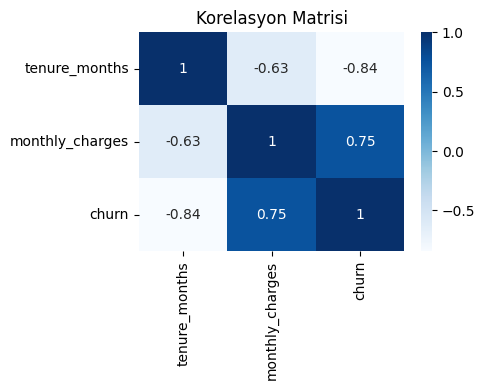

In [19]:
explore(df)